In [24]:
df = pd.read_csv('data/games.csv')
print(df.shape)
print(df.columns.tolist())

(122611, 39)
['AppID', 'Name', 'Release date', 'Estimated owners', 'Peak CCU', 'Required age', 'Price', 'DiscountDLC count', 'About the game', 'Supported languages', 'Full audio languages', 'Reviews', 'Header image', 'Website', 'Support url', 'Support email', 'Windows', 'Mac', 'Linux', 'Metacritic score', 'Metacritic url', 'User score', 'Positive', 'Negative', 'Score rank', 'Achievements', 'Recommendations', 'Notes', 'Average playtime forever', 'Average playtime two weeks', 'Median playtime forever', 'Median playtime two weeks', 'Developers', 'Publishers', 'Categories', 'Genres', 'Tags', 'Screenshots', 'Movies']


In [25]:
# Drop rows missing critical columns
df.dropna(subset=['Name', 'Genres', 'Price', 'Positive', 'Negative'], inplace=True)

# Fix price to numeric
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')
df.dropna(subset=['Price'], inplace=True)

# Engineer new columns
df['Total Reviews'] = df['Positive'] + df['Negative']
df['Rating Ratio'] = df['Positive'] / (df['Total Reviews'] + 1)
df['Price Type'] = df['Price'].apply(lambda x: 'Free' if x == 0 else 'Paid')

print(df.shape)
print(df['Price Type'].value_counts())

(114198, 42)
Price Type
Free    73576
Paid    40622
Name: count, dtype: int64


C:\Users\aadit\AppData\Local\Temp\ipykernel_31204\1084302651.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.values, y=top_genres.index, palette='viridis')


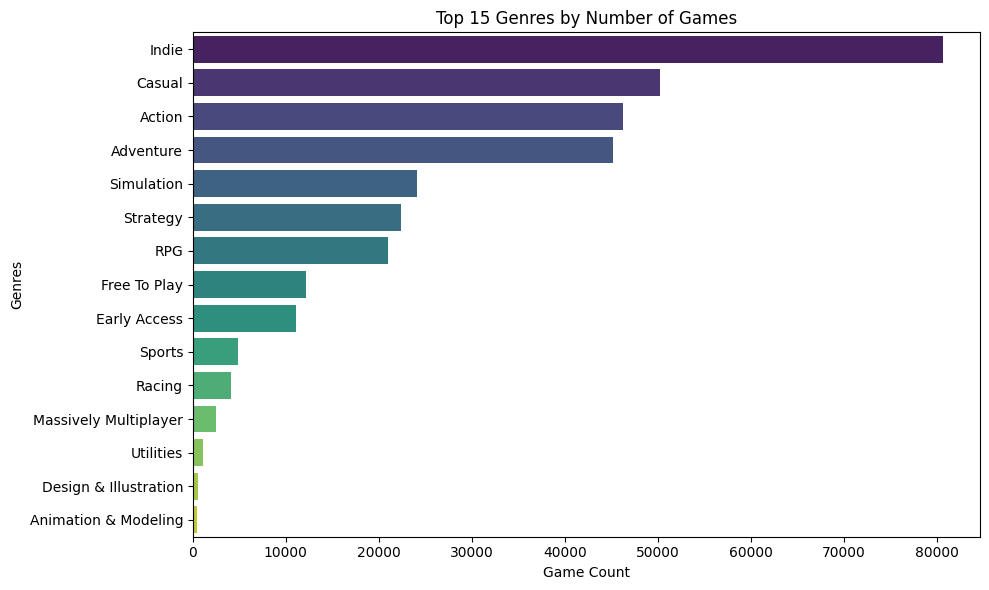

In [26]:
genre_series = df['Genres'].str.split(',').explode().str.strip()
top_genres = genre_series.value_counts().head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_genres.values, y=top_genres.index, palette='viridis')
plt.title('Top 15 Genres by Number of Games')
plt.xlabel('Game Count')
plt.tight_layout()
plt.savefig('outputs/top_genres.png', dpi=150)
plt.show()

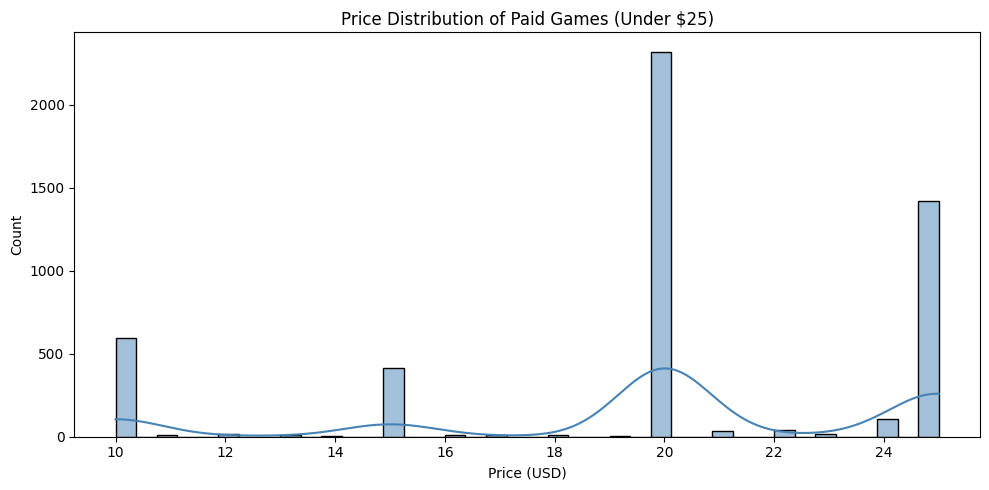

Median price: $51.0
Mean price: $55.32


In [27]:
paid = df[df['Price'] > 0]
paid_capped = paid[paid['Price'] <= 25]

plt.figure(figsize=(10, 5))
sns.histplot(paid_capped['Price'], bins=40, kde=True, color='steelblue')
plt.title('Price Distribution of Paid Games (Under $25)')
plt.xlabel('Price (USD)')
plt.tight_layout()
plt.savefig('outputs/price_dist.png', dpi=150)
plt.show()

print(f"Median price: ${paid['Price'].median()}")
print(f"Mean price: ${paid['Price'].mean():.2f}")

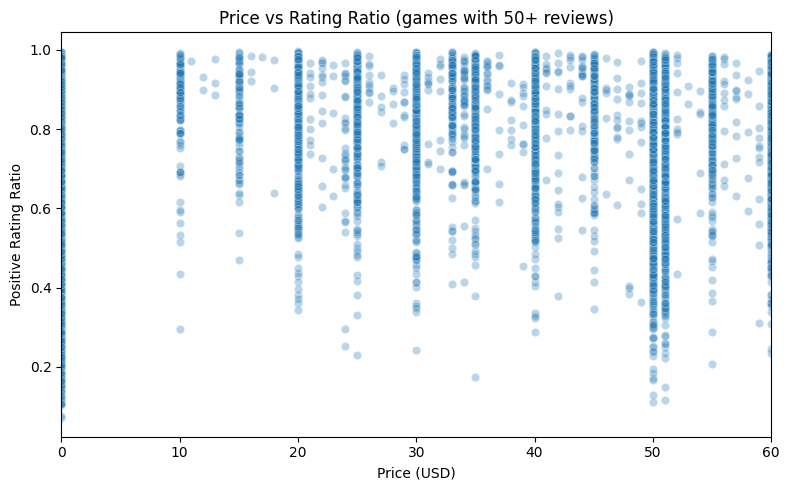

                 Price  Rating Ratio
Price         1.000000      0.015619
Rating Ratio  0.015619      1.000000


In [28]:
filtered = df[df['Total Reviews'] >= 50]

plt.figure(figsize=(8, 5))
sns.scatterplot(data=filtered, x='Price', y='Rating Ratio', alpha=0.3)
plt.xlim(0, 60)
plt.title('Price vs Rating Ratio (games with 50+ reviews)')
plt.xlabel('Price (USD)')
plt.ylabel('Positive Rating Ratio')
plt.tight_layout()
plt.savefig('outputs/price_vs_rating.png', dpi=150)
plt.show()

print(filtered[['Price', 'Rating Ratio']].corr())

C:\Users\aadit\AppData\Local\Temp\ipykernel_31204\537838636.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Total Reviews', y='Name', data=top_reviewed, palette='magma')


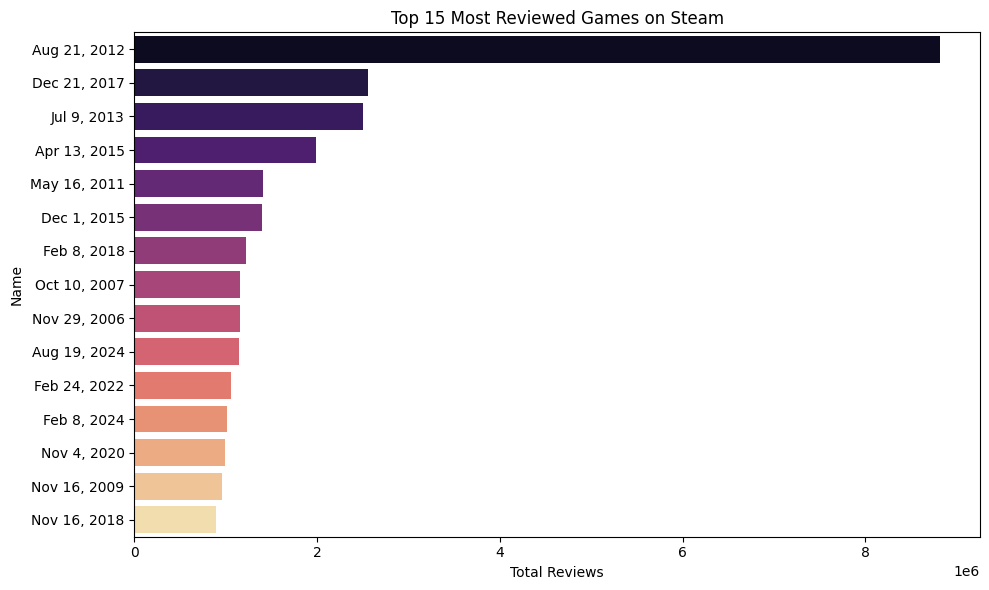

        Name  Total Reviews  Rating Ratio  Price
Aug 21, 2012        8815087      0.866932      0
Dec 21, 2017        2557944      0.594406      0
 Jul 9, 2013        2498969      0.815193      0
Apr 13, 2015        1990556      0.874117      0
May 16, 2011        1409473      0.974817     50
 Dec 1, 2015        1398584      0.838600      0
 Feb 8, 2018        1227784      0.872413     50
Oct 10, 2007        1161472      0.899086      0
Nov 29, 2006        1159707      0.967956     50
Aug 19, 2024        1150098      0.966630      0
Feb 24, 2022        1056677      0.928892     35
 Feb 8, 2024        1017635      0.762437     20
 Nov 4, 2020         994979      0.671424      0
Nov 16, 2009         963983      0.975349      0
Nov 16, 2018         894458      0.980367     20


In [29]:
top_reviewed = df.nlargest(15, 'Total Reviews')[['Name', 'Total Reviews', 'Rating Ratio', 'Price']]

plt.figure(figsize=(10, 6))
sns.barplot(x='Total Reviews', y='Name', data=top_reviewed, palette='magma')
plt.title('Top 15 Most Reviewed Games on Steam')
plt.xlabel('Total Reviews')
plt.tight_layout()
plt.savefig('outputs/top_reviewed.png', dpi=150)
plt.show()

print(top_reviewed.to_string(index=False))

In [30]:
genre_df = df[df['Total Reviews'] >= 50].copy()
genre_df = genre_df.assign(Genre=genre_df['Genres'].str.split(',')).explode('Genre')
genre_df['Genre'] = genre_df['Genre'].str.strip()

genre_stats = genre_df.groupby('Genre').agg(
    count=('Name', 'count'),
    avg_rating=('Rating Ratio', 'mean')
).sort_values('count', ascending=False).head(15)

print(genre_stats)

                       count  avg_rating
Genre                                   
Indie                  21073    0.785456
Adventure              13189    0.786578
Action                 12854    0.767916
Casual                 10254    0.790725
Simulation              7341    0.758448
RPG                     6837    0.775231
Strategy                6674    0.760376
Free To Play            2671    0.758083
Early Access            2223    0.736640
Sports                  1320    0.755821
Racing                  1060    0.751166
Massively Multiplayer    942    0.671177
Utilities                247    0.748227
Design & Illustration    162    0.783099
Animation & Modeling     136    0.767395


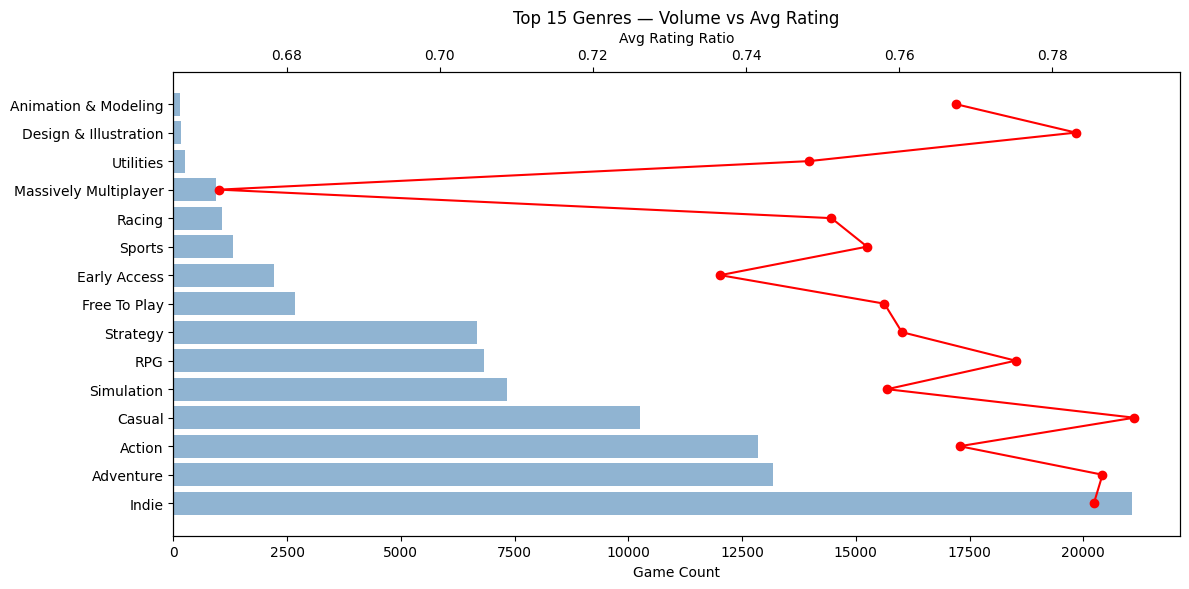

In [31]:
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.barh(genre_stats.index, genre_stats['count'], color='steelblue', alpha=0.6, label='Game Count')
ax1.set_xlabel('Game Count')

ax2 = ax1.twiny()
ax2.plot(genre_stats['avg_rating'], genre_stats.index, 'ro-', label='Avg Rating')
ax2.set_xlabel('Avg Rating Ratio')

plt.title('Top 15 Genres — Volume vs Avg Rating')
plt.tight_layout()
plt.savefig('outputs/genre_rating_comparison.png', dpi=150)
plt.show()

In [32]:
## Key Findings

1. **Indie dominates Steam** — 80k+ games, nearly double any other genre
2. **Price ≠ Quality** — correlation between price and rating is ~0.015 (essentially zero)
3. **Free games are more common** but paid games cluster at psychological price points ($10, $15, $20)
4. **[fill from genre_stats]** — e.g. "Action has high volume but [X] genre has higher avg rating"

SyntaxError: invalid character '—' (U+2014) (2193897066.py, line 3)